In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 🔹 Load dataset
df = pd.read_csv("ipl_salary.csv")

# 🔹 1 feature (visualization ke liye)
X = df[['runs']].values
y = df['salary_crore'].values

# 🔹 Scaling (VERY IMPORTANT for SVR ⚠️)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).ravel()

# 🔹 SVR Model
model = SVR(kernel='rbf')  # nonlinear regression
model.fit(X_scaled, y_scaled)

# 🔹 Prediction line
X_grid = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1,1)
y_pred = model.predict(X_grid)



In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 🔹 Prediction (test set pe karo ideally)
y_pred = model.predict(X_scaled)

# 🔹 Metrics
mae = mean_absolute_error(y_scaled, y_pred)
mse = mean_squared_error(y_scaled, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_scaled, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.565999239039538
MSE: 0.5033172546148496
RMSE: 0.7094485567078487
R2 Score: 0.49668274538515045


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 🔹 Single feature for graph
X = df[['runs']].values
y = df['salary_crore'].values

# 🔹 Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [15]:


X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).ravel()

# 🔹 Models
hard_model = SVR(kernel='rbf', C=100)   # Hard (strict)
soft_model = SVR(kernel='rbf', C=0.5)   # Soft (flexible)

hard_model.fit(X_scaled, y_scaled)
soft_model.fit(X_scaled, y_scaled)

# 🔹 Prediction grid
X_grid = np.linspace(X_scaled.min(), X_scaled.max(), 200).reshape(-1,1)

y_hard = hard_model.predict(X_grid)
y_soft = soft_model.predict(X_grid)

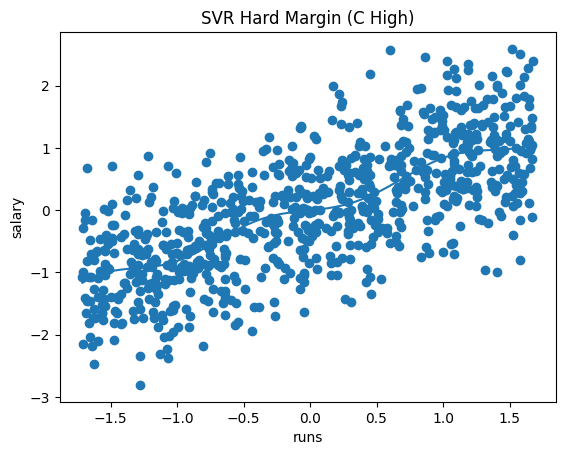

In [19]:
# Graph 1: Hard Margin
plt.figure()
plt.scatter(X_scaled, y_scaled)
plt.plot(X_grid, y_hard)
plt.title("SVR Hard Margin (C High)")
plt.xlabel("runs")
plt.ylabel("salary")
plt.show()


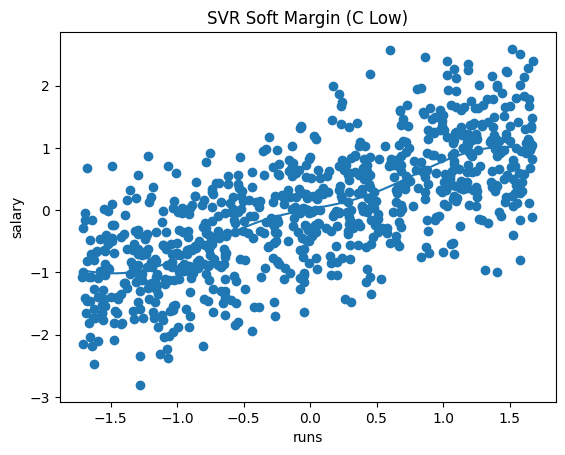

In [ ]:
# Graph 2: Soft Margin
plt.figure()
plt.scatter(X_scaled, y_scaled)
plt.plot(X_grid, y_soft)
plt.title("SVR Soft Margin (C Low)")
plt.xlabel("runs")
plt.ylabel("salary")
plt.show()



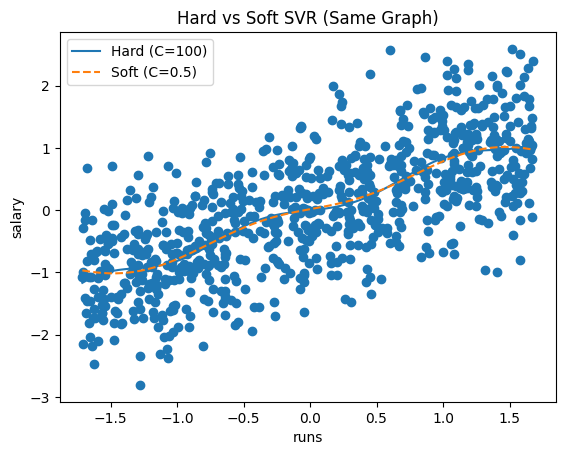

In [ ]:
#  Hard vs soft 
plt.figure()
plt.scatter(X_scaled, y_scaled)

plt.plot(X_grid, y_hard, linestyle='-', label='Hard (C=100)')
plt.plot(X_grid, y_soft, linestyle='--', label='Soft (C=0.5)')

plt.title("Hard vs Soft SVR (Same Graph)")
plt.xlabel("runs")
plt.ylabel("salary")
plt.legend()

plt.show()